In [1]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# Создание синтетического набора данных

In [2]:
# data_original = pd.read_csv("../Лаб 1/mental_health_digital_behavior_data.csv")
# data_original = pd.read_csv("../Лаб 1/Womens Clothing E-Commerce Reviews.csv")

# Parameters
mean = 100
std_dev = 25
rows = 500
np.random.seed(42)

data_original = pd.DataFrame()
with_missing = False
for i in range(5):
    data = np.random.normal(loc=mean-2*i, scale=std_dev+3*i, size=rows)
    # data_original[f'Random_data_{i}'] = pd.DataFrame(data, columns=['Random_Data'])
    if with_missing:
        mask = np.random.rand(rows) < 0.2
        # data_original[f'Random_data_{i}'][mask] = np.nan
        data[mask] = np.nan

    data_original[f'Random_data_{i}'] = data
    with_missing = not with_missing

data_original.head(25)

,Random_data_0,Random_data_1,Random_data_2,Random_data_3,Random_data_4
0,112.417854,NaN,84.675032,90.995659,78.693702
1,96.543392,NaN,101.725089,81.419625,103.140972
2,116.192213,58.840108,54.239085,85.200934,98.801877
3,138.075746,113.763139,65.879965,148.354004,191.642246
4,94.146166,NaN,133.212831,113.071261,104.942601
5,94.146576,84.360489,75.636277,83.953669,54.849980
6,139.480320,NaN,63.545760,117.696450,88.467823
7,119.185868,73.808258,112.636235,NaN,26.278886
8,88.263140,99.358606,132.756829,NaN,89.017809
9,113.564001,74.733397,118.287553,106.567835,61.176926


# Задание № 1: Вариант 7

Условие:

Для набора данных проведите устранение пропусков для одного (произвольного) числового признака с использованием метода заполнения медианой.

In [3]:
data_1 = pd.DataFrame(data_original['Random_data_1'])
data_1.isna().sum()

data_2 = pd.DataFrame(data_original['Random_data_4'])
data_2.isna().sum()

Random_data_4    0
dtype: int64

In [4]:
impute_mean = SimpleImputer(missing_values=np.nan,  strategy='constant', fill_value=data_1['Random_data_1'].mean())
data_Random_data_1 = pd.DataFrame(impute_mean.fit_transform(data_1))
print (data_1['Random_data_1'].mean())

99.41914214337626


In [5]:
data_Random_data_1.head(5)

,0
0,99.419142
1,99.419142
2,58.840108
3,113.763139
4,99.419142


Видим, что на позицию 0, 1 и 4 было подставлено среднее значение столбца.

In [6]:
data_original['Random_data_1'] = data_Random_data_1
data_original.head(15)

,Random_data_0,Random_data_1,Random_data_2,Random_data_3,Random_data_4
0,112.417854,99.419142,84.675032,90.995659,78.693702
1,96.543392,99.419142,101.725089,81.419625,103.140972
2,116.192213,58.840108,54.239085,85.200934,98.801877
3,138.075746,113.763139,65.879965,148.354004,191.642246
4,94.146166,99.419142,133.212831,113.071261,104.942601
5,94.146576,84.360489,75.636277,83.953669,54.849980
6,139.480320,99.419142,63.545760,117.696450,88.467823
7,119.185868,73.808258,112.636235,NaN,26.278886
8,88.263140,99.358606,132.756829,NaN,89.017809
9,113.564001,74.733397,118.287553,106.567835,61.176926


# Задание № 2: Вариант 27

Условие:

Для набора данных для одного (произвольного) числового признака проведите обнаружение и замену (найденными верхними и нижними границами) выбросов на основе 5% и 95% квантилей.

In [7]:
lower_boundary = data_2.quantile(0.05)
upper_boundary = data_2.quantile(0.95)
print (f'Нижняя граница = {lower_boundary}, а верхняя = {upper_boundary}')

Нижняя граница = Random_data_4    23.235742
Name: 0.05, dtype: float64, а верхняя = Random_data_4    153.271925
Name: 0.95, dtype: float64


In [8]:
# Флаги для удаления выбросов
# outliers_temp = np.where(data_2 > upper_boundary, True, 
#                          np.where(data_2 < lower_boundary, True, False))
data_2 = pd.DataFrame(np.where(data_2 > upper_boundary, upper_boundary, 
                                 np.where(data_2 < lower_boundary, lower_boundary, data_2)))
data_2[15:25]

,0
15,80.114018
16,153.271925
17,122.123615
18,109.836469
19,105.643126
20,106.570500
21,23.235742
22,81.681314
23,123.270845
24,90.190804


In [9]:
data_original['Random_data_4'] = data_2
print(data_original[:25])
print(data_original.isna().sum())

    Random_data_0  Random_data_1  Random_data_2  Random_data_3  Random_data_4
0      112.417854      99.419142      84.675032      90.995659      78.693702
1       96.543392      99.419142     101.725089      81.419625     103.140972
2      116.192213      58.840108      54.239085      85.200934      98.801877
3      138.075746     113.763139      65.879965     148.354004     153.271925
4       94.146166      99.419142     133.212831     113.071261     104.942601
5       94.146576      84.360489      75.636277      83.953669      54.849980
6      139.480320      99.419142      63.545760     117.696450      88.467823
7      119.185868      73.808258     112.636235            NaN      26.278886
8       88.263140      99.358606     132.756829            NaN      89.017809
9      113.564001      74.733397     118.287553     106.567835      61.176926
10      88.414558     105.572791     126.877478      90.351727     125.869440
11      88.356756      96.593333      72.539352            NaN  

В данном случае видно, что в последний столбец "Random_data_4" были занесены значения 153.271925 в 3-ю, 14-ю и 16-ю позицию и значение 23.235742 в 21-ую позицию.
Вместо этих значений в исходном наборе данных были: 191.642246, 156.337500, 159.804611 и 20.676115 соответственно

# Задание по группам: ИУ5-24М

Условие:

Для произвольной колонки данных построить график "Скрипичная диаграмма (violin plot)".


C:\Users\sorok\AppData\Local\Temp\ipykernel_3656\1784964556.py:26: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(data=corr_df, palette="Set3_r", bw=.2, cut=1, linewidth=1.5, inner="quartile")


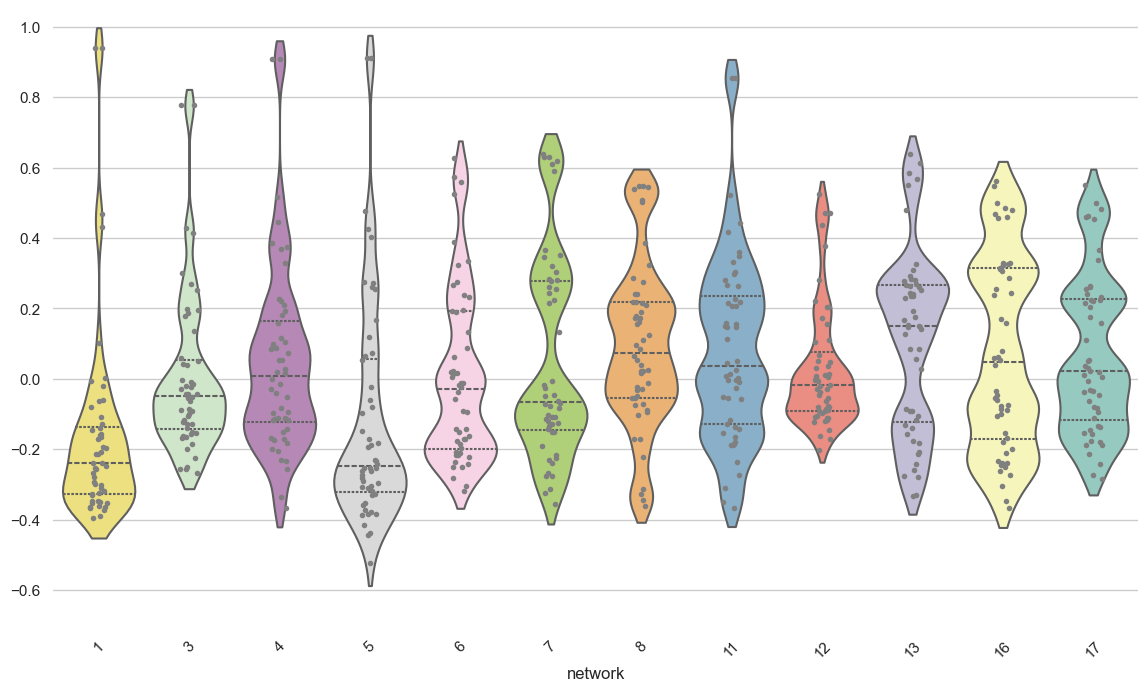

In [10]:
# https://habr.com/ru/articles/751898/ - источник про скрипичные диаграммы
# Импорт основаных библтотек
import seaborn as sns
import matplotlib.pyplot as plt

# Установка стиля диаграммы
sns.set_theme(style="whitegrid")

# Загрузка выборочного датасета
df = sns.load_dataset("brain_networks", header=[0, 1, 2], index_col=0)

# Выбираем любое подмножество
used_networks = [1, 3, 4, 5, 6, 7, 8, 11, 12, 13, 16, 17]
used_columns = (df.columns.get_level_values("network")
               .astype(int)
               .isin(used_networks))
df = df.loc[:, used_columns]

corr_df = df.corr().groupby(level="network").mean()
corr_df.index = corr_df.index.astype(int)
corr_df = corr_df.sort_index().T

# Отображение скрипичной диаграммы
f, ax = plt.subplots(figsize=(14, 8))
sns.violinplot(data=corr_df, palette="Set3_r", bw=.2, cut=1, linewidth=1.5, inner="quartile")
sns.stripplot(data=corr_df, color="gray", size=4, jitter=True)
ax.set(ylim=(-.7, 1.05))
plt.xticks(rotation=45)
sns.despine(left=True, bottom=True)
plt.show()

**Применение:**

Обычные скрипичные диаграммы подходят для визуализации распределения данных с одной переменной, особенно для демонстрации сравнений между несколькими категориями, например, для демонстрации распределения корреляций между различными нейронными связями в исследованиях мозга.

**Преимущества:**

Четко отображается распределение данных, включая медиану, квартиль и значения выбросов.

Данные из нескольких категорий могут быть сопоставлены одновременно, что помогает наблюдать различия между категориями.

Поддерживает пользовательские цветовые палитры и стили, чтобы сделать диаграмму более красивой.

**Недостатки:**

Он не подходит для сравнения между несколькими переменными, и необходимо использовать другие стили, такие как сгруппированная скрипичная диаграмм.

При большом объеме данных диаграмма может казаться переполненной и не подходить для отображения слишком большого количества категорий.